In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#importing seaborn for statistical plots
import seaborn as sns
# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [61]:
vehicle_df = pd.read_csv('/content/drive/My Drive/Machine Learning/Assignments/External/Residency 5 External Assignment/Assignment/Unsupervised Learning/PCA and SVM/vehicle.csv')
         
vehicle_df.head(10)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
5,107,NaN,106.0,172.0,50.0,6,255.0,26.0,28.0,169,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183,bus
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,bus
7,90,43.0,66.0,157.0,65.0,9,137.0,48.0,18.0,146,162.0,281.0,164.0,67.0,3.0,3.0,193.0,202,van
8,86,34.0,62.0,140.0,61.0,7,122.0,54.0,17.0,127,141.0,223.0,112.0,64.0,2.0,14.0,200.0,208,van
9,93,44.0,98.0,NaN,62.0,11,183.0,36.0,22.0,146,202.0,505.0,152.0,64.0,4.0,14.0,195.0,204,car


#1.Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)


In [62]:
vehicle_df.shape

(846, 19)

In [63]:
vehicle_df.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0


In [64]:
vehicle_df['circularity'].median()

44.0

In [65]:
vehicle_df['distance_circularity'].median()

80.0

In [66]:
vehicle_df['radius_ratio'].median()

167.0

In [67]:
vehicle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
compactness                    846 non-null int64
circularity                    841 non-null float64
distance_circularity           842 non-null float64
radius_ratio                   840 non-null float64
pr.axis_aspect_ratio           844 non-null float64
max.length_aspect_ratio        846 non-null int64
scatter_ratio                  845 non-null float64
elongatedness                  845 non-null float64
pr.axis_rectangularity         843 non-null float64
max.length_rectangularity      846 non-null int64
scaled_variance                843 non-null float64
scaled_variance.1              844 non-null float64
scaled_radius_of_gyration      844 non-null float64
scaled_radius_of_gyration.1    842 non-null float64
skewness_about                 840 non-null float64
skewness_about.1               845 non-null float64
skewness_about.2               845 non-null float64
hollows_ratio    

In [68]:
vehicle_df.isnull().sum() # we have many missing values. 

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

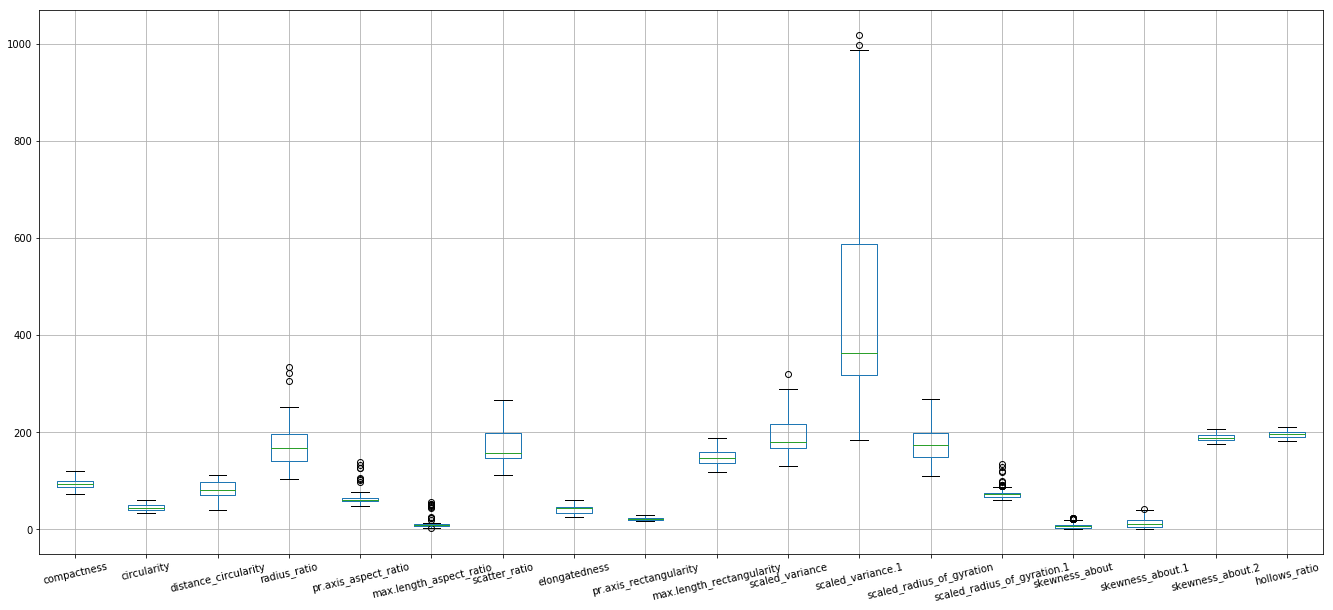

In [69]:
import matplotlib.pylab as plt

vehicle_df.boxplot(rot=13, figsize=(23, 10)) #we have to deal with outliers as well.

In [0]:
#replace missing value with mean

vehicle_df.fillna(vehicle_df.mean(), inplace=True)

In [71]:
vehicle_df.isnull().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [0]:
#handling outliers        

data = vehicle_df   
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('class').transform(replace)) 
vehicle_newdf = data_corrected.join(pd.DataFrame(vehicle_df['class']))

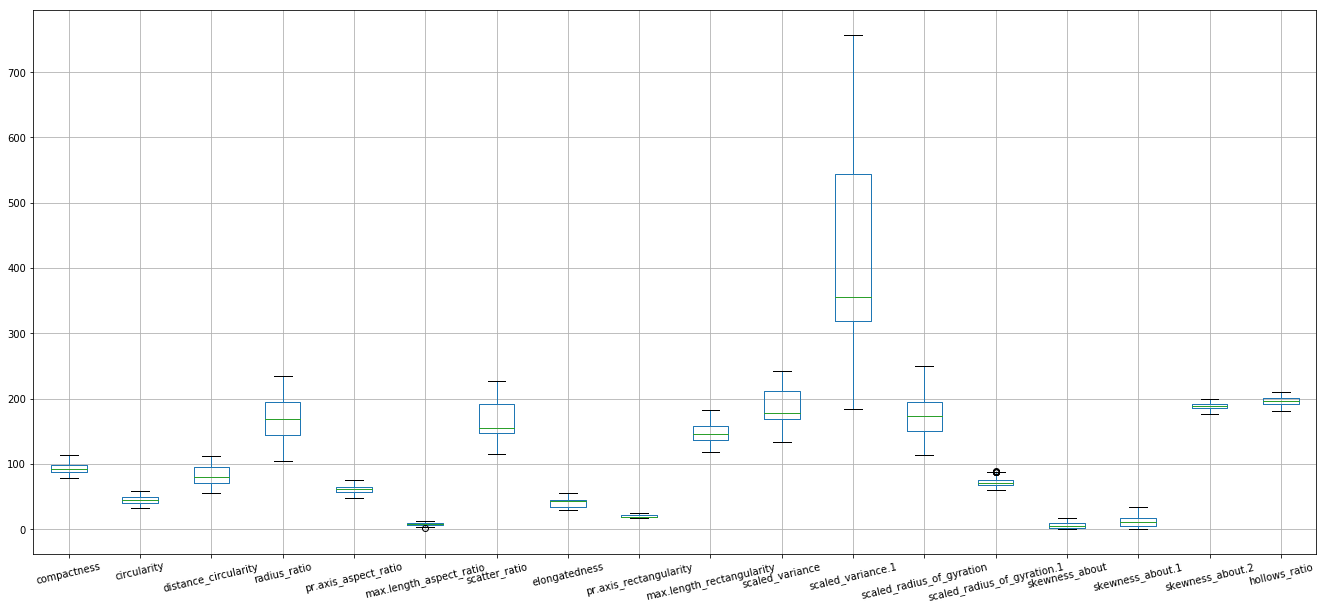

In [73]:
import matplotlib.pylab as plt

vehicle_newdf.boxplot(rot=13, figsize=(23, 10)) #outliers have been removed to a much extent

#2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

In [0]:
sns.pairplot(vehicle_newdf, diag_kind='kde')

Output hidden; open in https://colab.research.google.com to view.

In [0]:
vehicle_newdf.corr()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.636492,0.693558,0.692347,0.212192,0.517154,0.760192,-0.710495,0.758365,0.631202,0.686436,0.777130,0.507184,-0.272514,0.174447,0.186194,0.359163,0.385613
circularity,0.636492,1.000000,0.672814,0.581010,0.217931,0.601751,0.810845,-0.712519,0.788206,0.949455,0.704145,0.827441,0.915683,0.053020,0.132927,-0.005588,-0.003128,0.079237
distance_circularity,0.693558,0.672814,1.000000,0.736925,0.203868,0.672329,0.851330,-0.833273,0.858404,0.626251,0.809186,0.831487,0.573288,-0.255830,0.115282,0.267834,0.162643,0.374674
radius_ratio,0.692347,0.581010,0.736925,1.000000,0.583488,0.436308,0.780507,-0.794863,0.755812,0.501320,0.781311,0.770653,0.506608,-0.361924,0.034173,0.171898,0.427605,0.456753
pr.axis_aspect_ratio,0.212192,0.217931,0.203868,0.583488,1.000000,0.097656,0.269520,-0.304374,0.232740,0.155567,0.256221,0.280913,0.189926,-0.304777,-0.057227,-0.021777,0.449115,0.347809
max.length_aspect_ratio,0.517154,0.601751,0.672329,0.436308,0.097656,1.000000,0.641523,-0.553366,0.648339,0.646937,0.528434,0.623408,0.465778,-0.299558,0.079958,0.171177,0.078494,0.396306
scatter_ratio,0.760192,0.810845,0.851330,0.780507,0.269520,0.641523,1.000000,-0.921934,0.974095,0.758939,0.906440,0.978095,0.715560,-0.131874,0.078152,0.224488,0.156118,0.259752
elongatedness,-0.710495,-0.712519,-0.833273,-0.794863,-0.304374,-0.553366,-0.921934,1.000000,-0.926892,-0.642830,-0.934125,-0.900843,-0.628859,0.175167,-0.065525,-0.232736,-0.209600,-0.284909
pr.axis_rectangularity,0.758365,0.788206,0.858404,0.755812,0.232740,0.648339,0.974095,-0.926892,1.000000,0.740425,0.914361,0.956279,0.690824,-0.138291,0.085073,0.239455,0.140224,0.263558
max.length_rectangularity,0.631202,0.949455,0.626251,0.501320,0.155567,0.646937,0.758939,-0.642830,0.740425,1.000000,0.627521,0.777555,0.848382,0.066925,0.122151,0.005114,-0.028427,0.077588


In [0]:
vehicle_newdf = vehicle_newdf.drop(['class'],axis=1)



In [0]:
y = vehicle_df['class']


In [0]:
from sklearn import preprocessing
vehicle_newdf_scaled=preprocessing.scale(vehicle_newdf)
vehicle_newdf_scaled = pd.DataFrame(vehicle_newdf_scaled,columns=vehicle_newdf.columns) #scaled full data frame

In [24]:
vehicle_newdf_scaled.head()


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.222922,0.585858,0.010243,0.286005,2.005664,0.901656,-0.147514,0.182813,-0.170939,0.828622,-0.439733,-0.273052,0.357897,-0.293628,0.029002,0.517393,-0.262867,0.177733
1,-0.308697,-0.603183,0.080952,-0.925942,-0.740356,0.407614,-0.585172,0.628063,-0.606310,-0.320111,-0.670728,-0.587918,-0.510093,0.038961,0.738019,0.267940,0.107800,0.463593
2,1.419065,0.925584,1.636549,1.301420,0.907256,0.901656,1.367458,-1.301353,1.135172,0.756826,1.369730,1.371960,1.559731,0.205256,1.919714,-0.355692,-0.077533,0.034803
3,-0.042888,-0.603183,-0.060465,-0.336346,0.358052,0.407614,-0.753503,0.776480,-0.606310,-0.320111,-1.055720,-0.722860,-1.545005,-1.457692,0.029002,-0.230965,1.961139,1.607032
4,-1.106126,-0.093594,-0.908973,1.170399,0.541120,-1.074513,-0.585172,0.628063,-0.606310,-0.248315,2.062716,-0.620047,0.491434,0.704140,0.738019,-0.106239,-1.560205,-1.823285


In [0]:
from sklearn.decomposition import PCA
pca = PCA(n_components=18)
pca_components = pca.fit(vehicle_newdf_scaled)

In [29]:
X_pca = pca.transform(vehicle_newdf_scaled)
X_pca.shape

(846, 18)

In [30]:
pca.explained_variance_ratio_ 

array([0.52586834, 0.16372015, 0.0687241 , 0.06285373, 0.04876234,
       0.03366262, 0.02680991, 0.01722219, 0.01188213, 0.0082283 ,
       0.00757233, 0.00598549, 0.00571316, 0.0053394 , 0.003284  ,
       0.0019074 , 0.00159971, 0.00086469])

In [32]:
cum_var_exp = np.cumsum(pca.explained_variance_ratio_ )
cum_var_exp # 9 pca components cover more than 95% of variance.

array([0.52586834, 0.68958849, 0.7583126 , 0.82116633, 0.86992867,
       0.90359129, 0.93040119, 0.94762338, 0.95950551, 0.96773381,
       0.97530614, 0.98129163, 0.98700479, 0.99234419, 0.9956282 ,
       0.9975356 , 0.99913531, 1.        ])

In [0]:
df = pd.DataFrame(X_pca)
df_final = df.join(y)

In [0]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
pca_components = pca.fit(vehicle_newdf_scaled)
X_pca = pca.transform(vehicle_newdf_scaled)
df1 = pd.DataFrame(X_pca)
df_vehicle = df1.join(y)


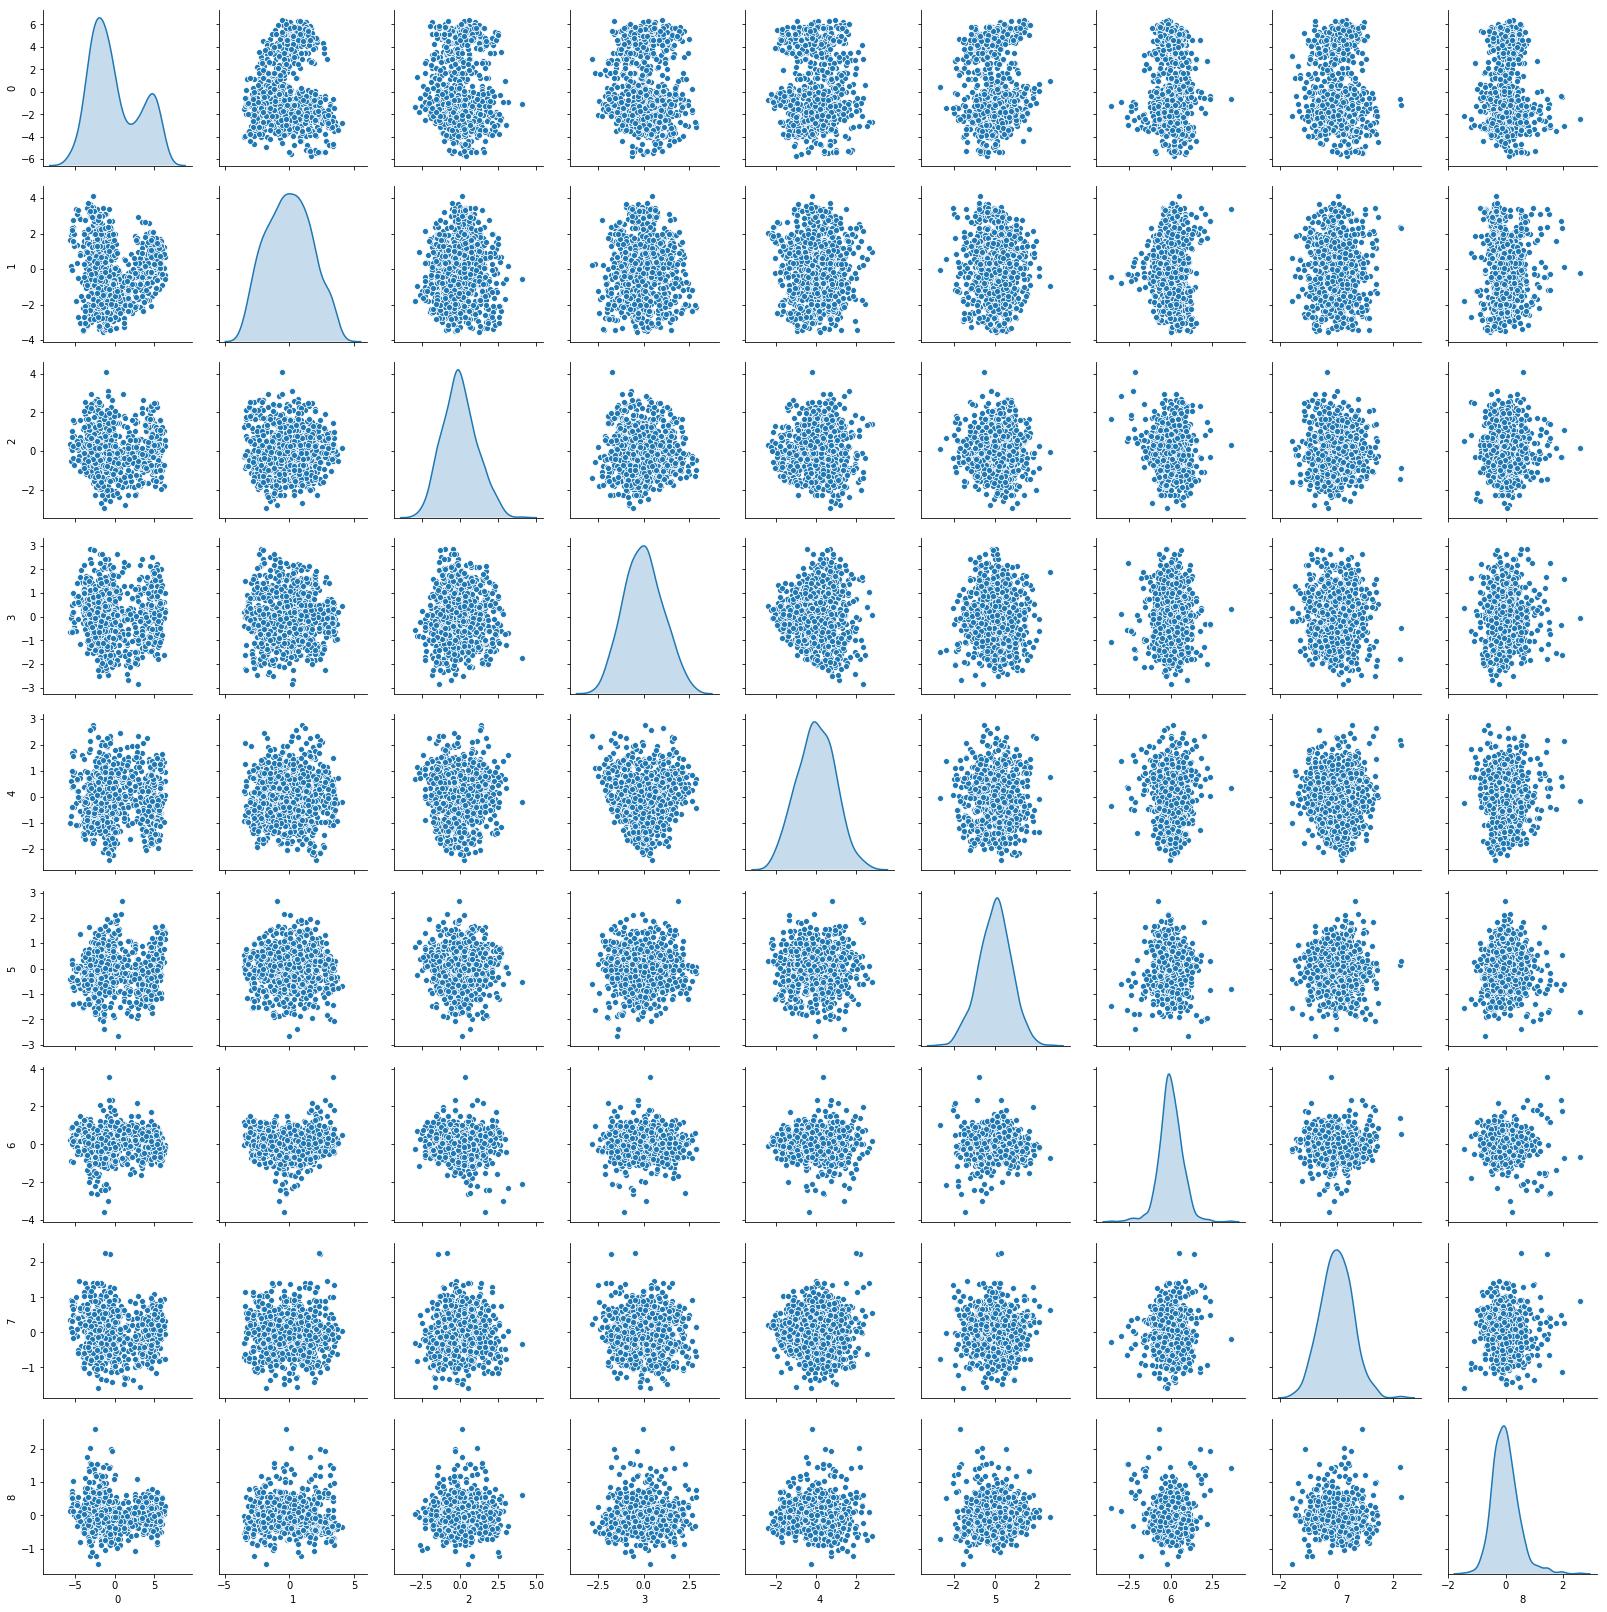

In [41]:
sns.pairplot(df_vehicle, diag_kind='kde') 

In [47]:
print(df_vehicle['class'].value_counts())

car    429
bus    218
van    199
Name: class, dtype: int64


# 4.Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [0]:
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
Y = labelencoder_Y.fit_transform(df_vehicle['class'])
X=df_vehicle.drop(['class'],axis=1)

In [0]:

from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=1)


In [0]:
from sklearn import svm
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV
model = svm.SVC()
parameters = {'C': [0.01, 0.05, 0.5, 1], 
              'kernel': ['linear', 'rbf']
             }
acc_scorer = make_scorer(accuracy_score)
grid_obj = GridSearchCV(model, parameters, scoring=acc_scorer)
grid_obj = grid_obj.fit(Xtrain, ytrain)


In [93]:
model = grid_obj.best_estimator_
model.fit(Xtrain, ytrain)  # c=1, kernel = rbf are the best parameters

SVC(C=1, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='rbf', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

In [94]:
predictions = model.predict(Xtest)
print(accuracy_score(ytest, predictions))

0.9606299212598425


In [97]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 

print(confusion_matrix(ytest, predictions))

[[ 58   1   0]
 [  2 127   4]
 [  2   1  59]]


In [98]:
print(classification_report(ytest, predictions))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        59
           1       0.98      0.95      0.97       133
           2       0.94      0.95      0.94        62

    accuracy                           0.96       254
   macro avg       0.95      0.96      0.96       254
weighted avg       0.96      0.96      0.96       254

